# 05 - Intersection and Union of Subspaces

This notebook is a standalone, executable study path for Chapter 5 of *Geometric Algebra for Computer Science*. The chapter asks a deceptively simple question: if blades represent subspaces, what algebraic operations should represent their geometric union and intersection?

The answer is the pair of products usually called **join** and **meet**. The join builds the smallest subspace containing the inputs. The meet finds the shared subspace, but with orientation and scale information that depend on the chosen ambient join. That dependence is why the products are powerful, and also why they need more care than the outer product alone.

Everything below is original exposition and coordinate code. The formulas are treated as executable geometry: each section includes a numerical invariant, an artifact, or an interactive visual that checks the idea.


## Route through the chapter

The chapter is short in page count but dense in consequences, so the notebook takes a slow path. First we separate two ideas that are often conflated: the **set** that a subspace represents and the **oriented blade** used to compute with it. The set view says that two planes share a line; the blade view says that the same shared line also has a direction and a weight, and both can change when the input order changes.

Second, we keep the join visible. It is tempting to ask for "the meet of A and B" as if the answer were independent of context. In practice the meet is computed relative to a space that contains both arguments. If the chosen containing space is the actual join, the result has the intended grade and scale. If the chosen containing space is too large, the computation may still return a useful warning signal: often a zero or near-zero quantity that says the incidence class has changed.

Third, we use two coordinate models. Vector subspaces through the origin are represented by column spans and by small GA blades. Offset affine objects are represented homogeneously, where an ordinary translated line becomes a linear object one dimension higher. This split is important because Chapter 5 postpones offset geometry to later models, but practical graphics code cannot wait that long; homogeneous coordinates give a controlled preview without pretending that offsets are ordinary vector subspaces.


## Printed-page audit

I verified the requested PDF span before writing the notebook. In this local copy, printed p. 125 begins on PDF page 156, so printed pp. 125-140 correspond to PDF pages 156-171.

The headings in that span are:

| Printed page | Heading |
|---:|---|
| 125 | 5 Intersection and Union of Subspaces; 5.1 The Phenomenology of Intersection |
| 127 | 5.2 Intersection Through Outer Factorization |
| 128 | 5.3 Relationships Between Meet and Join |
| 129 | 5.4 Using Meet and Join |
| 131 | 5.5 Join and Meet Are Mostly Linear |
| 132 | 5.6 Quantitative Properties of the Meet |
| 133 | 5.7 Linear Transformation of Meet and Join |
| 136 | 5.8 Offset Subspaces; 5.9 Further Reading |
| 137 | 5.10 Exercises; 5.10.1 Drills; 5.10.2 Structural Exercises |
| 138 | 5.11 Programming Examples and Exercises; 5.11.1 The Meet and Join |
| 139 | 5.11.2 Efficiency; 5.11.3 Floating Point Issues |

This notebook follows the conceptual route of those headings, with the exercises and programming sections represented by executable checks rather than copied problem text.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

PROJECT_ROOT = Path.cwd()
for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "utils" / "artifacts.py").exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.ga import Algebra
from utils.chapter05_meet_join import (
    Line3D,
    Plane3D,
    affine_line_slider_figure,
    blade_volume,
    homogeneous_intersection,
    homogeneous_line_from_points,
    homogeneous_point,
    join_basis,
    line_plane_intersection,
    line_plane_slider_figure,
    meet_basis,
    normalize,
    normalize_homogeneous,
    principal_angles,
    subspace_distance,
    transform_basis,
)

np.set_printoptions(precision=5, suppress=True)
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts"
ARTIFACT_TOPIC = "chapter-05"
PROJECT_ROOT


WindowsPath('D:/Geometry')

In [2]:
heading_audit = [
    {"printed_page": 125, "pdf_page": 156, "heading": "5 Intersection and Union of Subspaces"},
    {"printed_page": 125, "pdf_page": 156, "heading": "5.1 The Phenomenology of Intersection"},
    {"printed_page": 127, "pdf_page": 158, "heading": "5.2 Intersection Through Outer Factorization"},
    {"printed_page": 128, "pdf_page": 159, "heading": "5.3 Relationships Between Meet and Join"},
    {"printed_page": 129, "pdf_page": 160, "heading": "5.4 Using Meet and Join"},
    {"printed_page": 131, "pdf_page": 162, "heading": "5.5 Join and Meet Are Mostly Linear"},
    {"printed_page": 132, "pdf_page": 163, "heading": "5.6 Quantitative Properties of the Meet"},
    {"printed_page": 133, "pdf_page": 164, "heading": "5.7 Linear Transformation of Meet and Join"},
    {"printed_page": 136, "pdf_page": 167, "heading": "5.8 Offset Subspaces"},
    {"printed_page": 136, "pdf_page": 167, "heading": "5.9 Further Reading"},
    {"printed_page": 137, "pdf_page": 168, "heading": "5.10 Exercises"},
    {"printed_page": 137, "pdf_page": 168, "heading": "5.10.1 Drills"},
    {"printed_page": 137, "pdf_page": 168, "heading": "5.10.2 Structural Exercises"},
    {"printed_page": 138, "pdf_page": 169, "heading": "5.11 Programming Examples and Exercises"},
    {"printed_page": 138, "pdf_page": 169, "heading": "5.11.1 The Meet and Join"},
    {"printed_page": 139, "pdf_page": 170, "heading": "5.11.2 Efficiency"},
    {"printed_page": 139, "pdf_page": 170, "heading": "5.11.3 Floating Point Issues"},
]
heading_path = save_json(heading_audit, ARTIFACT_TOPIC, "pdf", "heading-audit.json", root=ARTIFACT_ROOT)
print(f"saved {heading_path}")


saved D:\Geometry\artifacts\chapter-05\pdf\heading-audit.json


## Why the outer product alone is not enough

The outer product is already a join when the input blades are independent: two different lines through the origin in a plane wedge into the plane they span, and three independent vectors wedge into a volume element. That success can hide the limitation. If the two inputs overlap, the outer product collapses to zero because repeated factors annihilate each other. Zero correctly says "not independent," but it does not say what the overlap is.

Intersection needs a product that can change grade. Two planes in 3-D usually share a line, so the answer should be a vector-like blade. If the planes coincide, the answer should be a plane-like blade. If a line merely pierces a plane through the origin, the intersection is the origin itself, represented in the algebra by a scalar weight. A fixed-grade bilinear product cannot express all of those outcomes as geometric objects without additional context.

The meet and join solve this by treating incidence as primary. The join asks for the minimal containing space. The meet asks what remains common after the inputs are compared inside that containing space. The price is that the products are not globally simple in the way ordinary addition is simple. Their behavior is piecewise: stable and linear while the incidence pattern stays fixed, then suddenly different when containment changes.


## Translation guide

A blade can be read as an oriented subspace with a scale. In the helper code we often store the same subspace as a matrix whose columns span it. That representation is intentionally humble: it makes the dimension checks, nullspaces, and floating-point failures visible.

| Geometric idea | Blade-language reading | Coordinate stand-in used here |
|---|---|---|
| Join `A ∪ B` | Smallest subspace containing both arguments | Column span of `[A B]` |
| Meet `A ∩ B` | Shared subspace, oriented relative to a join | Nullspace solution of `A x = B y` |
| Outer factorization | Split blades into common and complementary factors | A common basis plus residual directions |
| Quantitative meet | Scale records an angle-dependent weight | Sine checks from normalized blades |
| Offset subspaces | Move to a model where offsets are linear | Homogeneous lines and points |

The coordinate stand-ins do not replace the algebra. They make the algebra easier to audit.


## Meet and join as subspace operations

Start with two planes through the origin in ordinary 3-D space. One is the `xy` plane and the other is the `xz` plane. Their join should be all of 3-D space, while their meet should be the shared `x` axis.

The join is easy to compute from coordinates: put all spanning vectors in one matrix and take its column span. The meet takes one more step: solve `A x = B y`, because a vector in the intersection must have coordinates in both bases.


In [3]:
E3 = np.eye(3)
xy_plane = E3[:, [0, 1]]
xz_plane = E3[:, [0, 2]]
x_axis = E3[:, [0]]

J = join_basis(xy_plane, xz_plane)
M = meet_basis(xy_plane, xz_plane)

checks = {
    "dim_xy_plane": xy_plane.shape[1],
    "dim_xz_plane": xz_plane.shape[1],
    "dim_join": J.shape[1],
    "dim_meet": M.shape[1],
    "dim_identity_left": xy_plane.shape[1] + xz_plane.shape[1],
    "dim_identity_right": M.shape[1] + J.shape[1],
    "meet_distance_from_x_axis": subspace_distance(M, x_axis),
    "xy_plane_volume": blade_volume(xy_plane),
    "xz_plane_volume": blade_volume(xz_plane),
}

assert checks["dim_join"] == 3
assert checks["dim_meet"] == 1
assert checks["dim_identity_left"] == checks["dim_identity_right"]
assert checks["meet_distance_from_x_axis"] < 1e-9

path = save_json(checks, ARTIFACT_TOPIC, "checks", "basic-meet-join.json", root=ARTIFACT_ROOT)
print(checks)
print(f"saved {path}")


{'dim_xy_plane': 2, 'dim_xz_plane': 2, 'dim_join': 3, 'dim_meet': 1, 'dim_identity_left': 4, 'dim_identity_right': 4, 'meet_distance_from_x_axis': 0.0, 'xy_plane_volume': 1.0, 'xz_plane_volume': 1.0}
saved D:\Geometry\artifacts\chapter-05\checks\basic-meet-join.json


## The same example as blades

The little `utils.ga` algebra gives us enough blade arithmetic to see the orientation that the pure subspace calculation suppresses. The same two planes have an unoriented meet equal to the `x` axis, but the sign depends on how the input blades are ordered and oriented.


In [4]:
ga3 = Algebra([1, 1, 1], names=["e1", "e2", "e3"])
e1, e2, e3 = ga3.basis()

A_xy = e1.wedge(e2)
B_xz = e3.wedge(e1)
M_blade = A_xy.meet(B_xz)
J_blade = e1.wedge(e2).wedge(e3)

blade_checks = {
    "A_xy": repr(A_xy),
    "B_xz": repr(B_xz),
    "selected_join": repr(J_blade),
    "A_meet_B": repr(M_blade),
    "B_meet_A": repr(B_xz.meet(A_xy)),
}

assert M_blade.almost_equal(e1)
assert B_xz.meet(A_xy).almost_equal(-e1)
print(blade_checks)


{'A_xy': 'e1^e2', 'B_xz': '-e1^e3', 'selected_join': 'e1^e2^e3', 'A_meet_B': 'e1', 'B_meet_A': '-e1'}


## Outer factorization

Outer factorization is the cleanest way to read the geometry. If two blades share a factor, that common factor is their meet. The remaining factors, wedged with the common one, build the join.

Here the two planes are deliberately written with the common factor first in one blade and last in the other. That exposes the sign bookkeeping: the same unoriented line can appear with either orientation depending on the order in which factors are assembled.


A useful way to debug meet and join code is to imagine peeling factors off the blades. Suppose `A = C ^ A_rest` and `B = B_rest ^ C`, where `C` is the shared attitude. The meet should recover `C`, up to the sign forced by the ordering of the factors. The join should contain `C`, `A_rest`, and `B_rest` exactly once.

This is also a good mental model for implementation. Algorithms rarely receive perfectly factored symbolic blades. They receive coordinates, noisy inputs, and nearly repeated directions. Still, the algorithm is trying to discover the same structure: which part of the span is common, which part is unique to each argument, and whether the unique parts together form the containing join. The nullspace method in this notebook is a coordinate version of that discovery process.


In [5]:
common = e1
residual_A = e2
residual_B = e3

A_factored = common.wedge(residual_A)
B_factored = residual_B.wedge(common)
J_factored = common.wedge(residual_A).wedge(residual_B)
M_factored = A_factored.meet(B_factored)

factorization = {
    "common_factor": repr(common),
    "A = common ^ residual_A": repr(A_factored),
    "B = residual_B ^ common": repr(B_factored),
    "join": repr(J_factored),
    "meet": repr(M_factored),
}

assert M_factored.almost_equal(common)
assert J_factored.almost_equal(ga3.pseudoscalar())
print(factorization)


{'common_factor': 'e1', 'A = common ^ residual_A': 'e1^e2', 'B = residual_B ^ common': '-e1^e3', 'join': 'e1^e2^e3', 'meet': 'e1'}


## Sign and argument order

Meet behaves like an oriented product, not like an unordered set intersection. For two distinct lines through the origin in an oriented plane, the meet is a scalar weight. Reversing the order reverses the sign.

That sign is useful. In ray tests and surface tests, it says which side of an oriented boundary the incident object comes from. Throwing it away too early loses information the algebra intentionally preserved.


There are two layers of sign to keep separate. One layer is the orientation of each input blade: reversing a line direction or swapping two plane factors changes the blade sign while preserving the unoriented geometric set. The other layer is the order of the meet operation itself. Just as `a ^ b` and `b ^ a` differ by a sign for vectors, many meets also change sign when their arguments are exchanged.

The notebook checks this with a two-line example because scalars make the sign impossible to miss. The same issue appears in higher grades, but it is easier to accidentally hide it by normalizing a direction vector or plotting an unoriented line. In real computations, especially visibility tests and ray-surface tests, the sign is often the useful part of the answer.


In [6]:
ga2 = Algebra([1, 1], names=["e1", "e2"])
f1, f2 = ga2.basis()

theta = np.deg2rad(35.0)
a = f1
b = np.cos(theta) * f1 + np.sin(theta) * f2

ab = a.meet(b).scalar_value()
ba = b.meet(a).scalar_value()
wedge_ab = a.wedge(b)

sign_checks = {
    "theta_degrees": 35.0,
    "a_meet_b": ab,
    "b_meet_a": ba,
    "a_wedge_b": repr(wedge_ab),
    "expected_sine": float(np.sin(theta)),
}

assert np.isclose(ab, -np.sin(theta))
assert np.isclose(ba, np.sin(theta))
assert np.isclose(ab, -ba)
print(sign_checks)


{'theta_degrees': 35.0, 'a_meet_b': -0.573576436351046, 'b_meet_a': 0.573576436351046, 'a_wedge_b': '0.573576e1^e2', 'expected_sine': 0.573576436351046}


In [7]:
plane_xy = e1.wedge(e2)
line_from_below = e1 - 0.40 * e3
line_from_above = e1 + 0.40 * e3

piercing_checks = {
    "below_meets_plane": line_from_below.meet(plane_xy).scalar_value(),
    "above_meets_plane": line_from_above.meet(plane_xy).scalar_value(),
}

assert piercing_checks["below_meets_plane"] < 0
assert piercing_checks["above_meets_plane"] > 0
print(piercing_checks)


{'below_meets_plane': -0.4, 'above_meets_plane': 0.4}


## Mostly-linear behavior

Once a join has been selected, the meet formula is linear in the inputs inside that region of the problem. The catch is that the selected join can stop being the correct one.

The sweep below uses the full 3-D pseudoscalar as the join for a line meeting the `xy` plane. As the line direction approaches the plane, the full-space meet weight approaches zero. At exactly the degenerate case, the right geometric meet is no longer a scalar weight: the line is contained in the plane, so the meet jumps to a line.


The phrase "mostly linear" is practical rather than philosophical. If every input in a sweep keeps the same join, a meet formula based on that join behaves like a linear map of the input coordinates. Numerical code can exploit that. Small perturbations produce small changes, interpolation is meaningful, and tests can be written against ordinary residuals.

At degeneracy, though, the correct join changes. In the sweep below, a line that was not contained in the plane becomes contained in it. The full 3-D join is no longer minimal. The scalar meet computed with that full join goes to zero, which is not a failure; it is the algebra telling us that the old case no longer describes the geometry. The proper meet has changed grade from scalar to vector.


saved D:\Geometry\artifacts\chapter-05\plots\mostly-linear-meet.png


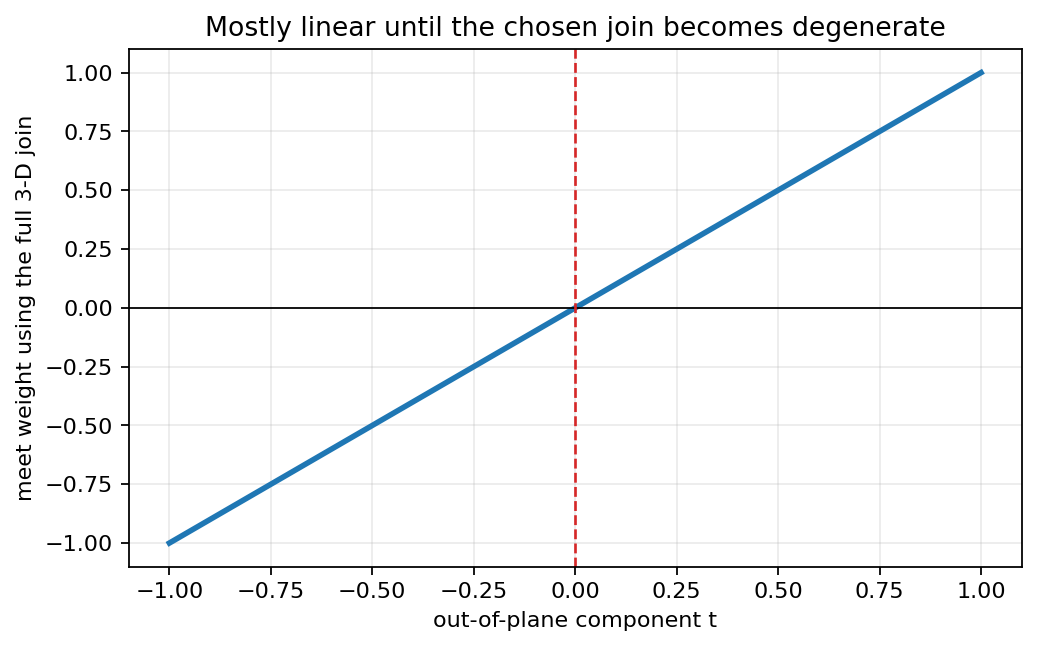

In [8]:
ts = np.linspace(-1.0, 1.0, 161)
full_join_meet_weights = np.array([(e1 + t * e3).meet(plane_xy).scalar_value() for t in ts])

contained_line_basis = E3[:, [0]]
contained_plane_basis = E3[:, [0, 1]]
proper_degenerate_meet = meet_basis(contained_line_basis, contained_plane_basis)

assert np.allclose(full_join_meet_weights, ts)
assert proper_degenerate_meet.shape[1] == 1
assert subspace_distance(proper_degenerate_meet, x_axis) < 1e-9

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(ts, full_join_meet_weights, color="#1f77b4", linewidth=2.5)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.axvline(0.0, color="#d62728", linewidth=1.2, linestyle="--")
ax.set_xlabel("out-of-plane component t")
ax.set_ylabel("meet weight using the full 3-D join")
ax.set_title("Mostly linear until the chosen join becomes degenerate")
ax.grid(True, alpha=0.25)
plot_path = save_matplotlib(fig, ARTIFACT_TOPIC, "plots", "mostly-linear-meet.png", root=ARTIFACT_ROOT)
plt.close(fig)
print(f"saved {plot_path}")
display_artifact(plot_path, width=720)


## Quantitative meet

When the blades and the join are normalized, the magnitude of the meet can be read as a sine-like measure of attitude. For two lines in a plane, that weight is the sine of their directed angle. For two planes in 3-D that share a line, the same sine appears as the magnitude of the line-valued meet.


{'max_line_error': 1.2246467991473532e-16, 'max_plane_error': 1.2246467991473532e-16}


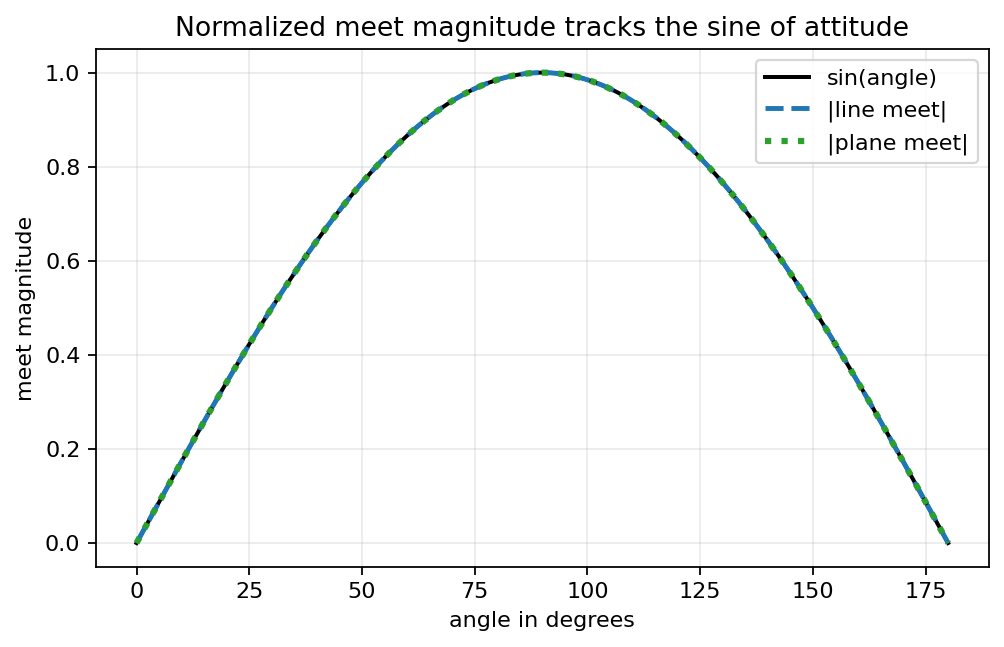

In [9]:
angles = np.linspace(0.0, np.pi, 181)
line_meet_magnitudes = []
plane_meet_magnitudes = []
for angle in angles:
    moving_line = np.cos(angle) * f1 + np.sin(angle) * f2
    line_meet_magnitudes.append(abs(f1.meet(moving_line).scalar_value()))

    moving_plane = e1.wedge(np.cos(angle) * e2 + np.sin(angle) * e3)
    plane_meet_magnitudes.append(A_xy.meet(moving_plane).norm())

line_meet_magnitudes = np.array(line_meet_magnitudes)
plane_meet_magnitudes = np.array(plane_meet_magnitudes)
expected = np.sin(angles)

assert np.max(np.abs(line_meet_magnitudes - expected)) < 1e-10
assert np.max(np.abs(plane_meet_magnitudes - expected)) < 1e-10

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.plot(np.rad2deg(angles), expected, label="sin(angle)", color="black", linewidth=1.8)
ax.plot(np.rad2deg(angles), line_meet_magnitudes, "--", label="|line meet|", color="#1f77b4", linewidth=2.2)
ax.plot(np.rad2deg(angles), plane_meet_magnitudes, ":", label="|plane meet|", color="#2ca02c", linewidth=2.8)
ax.set_xlabel("angle in degrees")
ax.set_ylabel("meet magnitude")
ax.set_title("Normalized meet magnitude tracks the sine of attitude")
ax.legend()
ax.grid(True, alpha=0.25)
plot_path = save_matplotlib(fig, ARTIFACT_TOPIC, "plots", "quantitative-meet.png", root=ARTIFACT_ROOT)
plt.close(fig)

quantitative_checks = {
    "max_line_error": float(np.max(np.abs(line_meet_magnitudes - expected))),
    "max_plane_error": float(np.max(np.abs(plane_meet_magnitudes - expected))),
}
save_json(quantitative_checks, ARTIFACT_TOPIC, "checks", "quantitative-meet.json", root=ARTIFACT_ROOT)
print(quantitative_checks)
display_artifact(plot_path, width=720)


## Linear transformations preserve the structure

A general invertible linear transformation distorts lengths and angles, so it does not preserve every metric measurement. It does preserve incidence structure: transform the inputs first and then meet/join, or meet/join first and then transform the result. The subspace should be the same either way.


In [10]:
F = np.array(
    [
        [1.20, 0.30, -0.10],
        [-0.25, 1.05, 0.35],
        [0.18, -0.08, 0.92],
    ]
)
assert abs(np.linalg.det(F)) > 1e-6

A = E3[:, [0, 1]]
B = np.column_stack([E3[:, 0], normalize([0.20, 0.45, 1.00])])
M_before = meet_basis(A, B)
J_before = join_basis(A, B)

FA = transform_basis(F, A)
FB = transform_basis(F, B)
M_after = meet_basis(FA, FB)
J_after = join_basis(FA, FB)

M_expected = transform_basis(F, M_before)
J_expected = transform_basis(F, J_before)

transform_checks = {
    "determinant_F": float(np.linalg.det(F)),
    "meet_subspace_error": subspace_distance(M_after, M_expected),
    "join_subspace_error": subspace_distance(J_after, J_expected),
    "principal_angle_meet_degrees": np.rad2deg(principal_angles(M_after, M_expected)).tolist(),
}

assert transform_checks["meet_subspace_error"] < 1e-9
assert transform_checks["join_subspace_error"] < 1e-9
path = save_json(transform_checks, ARTIFACT_TOPIC, "checks", "linear-transformation.json", root=ARTIFACT_ROOT)
print(transform_checks)
print(f"saved {path}")


{'determinant_F': 1.2976, 'meet_subspace_error': 1.2905363344731211e-15, 'join_subspace_error': 8.103755061164146e-16, 'principal_angle_meet_degrees': [0.0]}
saved D:\Geometry\artifacts\chapter-05\checks\linear-transformation.json


## Offset subspaces need a model

The subspaces above all pass through the origin. Ordinary blades of vectors are excellent for those, but an offset line such as `y = 1` is not a vector subspace of `R^2`. Homogeneous coordinates repair this by representing affine points as rays in a one-dimension-larger vector space.

In this model, the join of two points is a line, and the meet of two lines is a point. Parallel affine lines meet at a homogeneous point with last coordinate zero: a point at infinity.


This distinction is one reason geometric algebra texts move through several models of geometry. A Euclidean vector algebra is excellent for attitudes through the origin: directions, planes through the origin, and linear transformations. Affine geometry asks for more: points away from the origin, parallel lines, and translations. Homogeneous coordinates add a scale coordinate so that offset incidence becomes linear again.

The homogeneous examples here are intentionally modest. They are not a full projective geometric algebra implementation. They are a bridge between the Chapter 5 formulas and the later models where offset subspaces can be represented as blades directly. The important habit is already present: keep the object homogeneous until the last responsible moment, then normalize only if the last coordinate is safely nonzero.


In [11]:
p = homogeneous_point(-1.0, 0.0)
q = homogeneous_point(2.0, 1.5)
r = homogeneous_point(-0.5, 1.2)
s = homogeneous_point(1.4, -0.4)

line_a = homogeneous_line_from_points(p, q)
line_b = homogeneous_line_from_points(r, s)
finite_meet = homogeneous_intersection(line_a, line_b)
finite_affine = normalize_homogeneous(finite_meet)

parallel_a = homogeneous_line_from_points(homogeneous_point(-1.0, 0.0), homogeneous_point(1.0, 0.0))
parallel_b = homogeneous_line_from_points(homogeneous_point(-1.0, 1.0), homogeneous_point(1.0, 1.0))
infinity_meet = homogeneous_intersection(parallel_a, parallel_b)

offset_checks = {
    "line_a": line_a.tolist(),
    "line_b": line_b.tolist(),
    "finite_meet_homogeneous": finite_meet.tolist(),
    "finite_meet_affine": finite_affine[:2].tolist(),
    "parallel_meet_homogeneous": infinity_meet.tolist(),
}

assert abs(line_a @ finite_meet) < 1e-9
assert abs(line_b @ finite_meet) < 1e-9
assert abs(infinity_meet[-1]) < 1e-12
path = save_json(offset_checks, ARTIFACT_TOPIC, "checks", "offset-subspaces.json", root=ARTIFACT_ROOT)
print(offset_checks)
print(f"saved {path}")


{'line_a': [-1.5, 3.0, -1.5], 'line_b': [1.6, 1.9, -1.48], 'finite_meet_homogeneous': [-1.5899999999999999, -4.62, -7.65], 'finite_meet_affine': [0.20784313725490194, 0.6039215686274509], 'parallel_meet_homogeneous': [-4.0, 0.0, 0.0]}
saved D:\Geometry\artifacts\chapter-05\checks\offset-subspaces.json


## Interactive visual: line-plane meet

The next cell builds a Plotly slider scene. Drag the slider to change the line's tilt. The green point is the meet of the line and the plane. The algebraic version carries orientation and scale; the coordinate version below makes the incidence constraint visible.


In [12]:
line_plane_fig = line_plane_slider_figure()
line_plane_path = save_plotly_html(
    line_plane_fig,
    ARTIFACT_TOPIC,
    "interactive",
    "line-plane-intersection.html",
    root=ARTIFACT_ROOT,
    include_plotlyjs=True,
)

sample_line = Line3D(np.array([-1.05, -0.55, -0.70]), np.array([1.0, 0.28, 0.70]))
sample_plane = Plane3D(np.zeros(3), np.array([0.0, 0.0, 1.0]))
sample_hit = line_plane_intersection(sample_line, sample_plane)
assert sample_hit.point is not None
assert abs(sample_plane.signed_distance(sample_hit.point)) < 1e-10

print(f"saved {line_plane_path}")
display(line_plane_fig)


saved D:\Geometry\artifacts\chapter-05\interactive\line-plane-intersection.html


## Interactive visual: offset line meet

This second slider uses homogeneous coordinates in the plane. As the moving line becomes nearly parallel to the fixed line, the affine intersection runs away. Homogeneous coordinates still return a finite projective object; the last coordinate tells us whether the affine point is finite.


In [13]:
affine_fig = affine_line_slider_figure()
affine_path = save_plotly_html(
    affine_fig,
    ARTIFACT_TOPIC,
    "interactive",
    "homogeneous-line-meet.html",
    root=ARTIFACT_ROOT,
    include_plotlyjs=True,
)
print(f"saved {affine_path}")
display(affine_fig)


saved D:\Geometry\artifacts\chapter-05\interactive\homogeneous-line-meet.html


## Floating-point issues

Meet and join algorithms are sensitive near degeneracy because the answer changes type or moves toward infinity. A nearly parallel pair of affine lines is a good stress test: the homogeneous meet is well-defined, but normalizing by a tiny last coordinate produces huge affine coordinates.

The invariant to check is not whether the coordinates look modest. It is whether the homogeneous point still satisfies both line equations and whether the algorithm has noticed the small denominator.


Floating-point trouble is not only a matter of roundoff in arithmetic. It is often a modeling signal. A tiny denominator can mean that two lines are nearly parallel, two planes are nearly coincident, or a selected join is nearly wrong. Good code should expose that signal instead of flattening it into an apparently ordinary coordinate answer.

The table printed by the next cell keeps the homogeneous residuals beside the affine coordinates. The residuals answer the incidence question: does the computed point lie on both lines? The affine coordinates answer a different question: is it safe and useful to display the result in the current chart? Near parallelism, those two answers diverge. The projective point remains meaningful, while the affine chart becomes numerically hostile.


In [14]:
near_parallel_rows = []
fixed_slope = 0.5
fixed_intercept = -0.15
moving_intercept = 0.65
fixed_line = homogeneous_line_from_points(
    homogeneous_point(-1.0, fixed_slope * -1.0 + fixed_intercept),
    homogeneous_point(1.0, fixed_slope * 1.0 + fixed_intercept),
)

for delta in [1e-1, 1e-2, 1e-3, 1e-5, 1e-7, 0.0]:
    moving_slope = fixed_slope + delta
    moving_line = homogeneous_line_from_points(
        homogeneous_point(-1.0, moving_slope * -1.0 + moving_intercept),
        homogeneous_point(1.0, moving_slope * 1.0 + moving_intercept),
    )
    meet = homogeneous_intersection(fixed_line, moving_line)
    row = {
        "slope_delta": float(delta),
        "homogeneous_w": float(meet[-1]),
        "residual_line_a": float(fixed_line @ meet),
        "residual_line_b": float(moving_line @ meet),
    }
    if abs(meet[-1]) > 1e-12:
        affine = normalize_homogeneous(meet)
        row["affine_x"] = float(affine[0])
        row["affine_y"] = float(affine[1])
    else:
        row["affine_x"] = None
        row["affine_y"] = None
    near_parallel_rows.append(row)

for row in near_parallel_rows:
    assert abs(row["residual_line_a"]) < 1e-8
    assert abs(row["residual_line_b"]) < 1e-8
assert near_parallel_rows[-1]["affine_x"] is None

path = save_json(near_parallel_rows, ARTIFACT_TOPIC, "checks", "floating-point-near-parallel.json", root=ARTIFACT_ROOT)
for row in near_parallel_rows:
    print(row)
print(f"saved {path}")


{'slope_delta': 0.1, 'homogeneous_w': 0.3999999999999999, 'residual_line_a': -1.1102230246251565e-16, 'residual_line_b': -3.3306690738754696e-16, 'affine_x': -8.000000000000002, 'affine_y': -4.150000000000001}
{'slope_delta': 0.01, 'homogeneous_w': 0.040000000000000036, 'residual_line_a': 1.734723475976807e-18, 'residual_line_b': -1.3877787807814457e-17, 'affine_x': -79.99999999999994, 'affine_y': -40.14999999999997}
{'slope_delta': 0.001, 'homogeneous_w': 0.0040000000000000036, 'residual_line_a': 1.3335686721571705e-16, 'residual_line_b': 3.1051550219984847e-16, 'affine_x': -799.9999999999993, 'affine_y': -400.14999999999964}
{'slope_delta': 1e-05, 'homogeneous_w': 3.999999999981796e-05, 'residual_line_a': 4.4409937424542967e-17, 'residual_line_b': -4.4411631490437475e-17, 'affine_x': -80000.00000036409, 'affine_y': -40000.150000182046}
{'slope_delta': 1e-07, 'homogeneous_w': 3.9999999978945766e-07, 'residual_line_a': -2.220445784552517e-16, 'residual_line_b': -2.220446049250313e-16, 

## Final sanity checks

Before treating the notebook as a chapter replacement, the last pass should confirm more than "the cells run." The checks accumulated above cover several failure modes:

- ranks and subspace distances confirm that meet and join return the expected dimensions;
- blade comparisons confirm that orientation signs are not silently erased;
- sine plots confirm that the meet scale has the advertised quantitative meaning when blades and joins are normalized;
- transformation checks confirm that incidence survives an invertible linear map;
- homogeneous residuals confirm that offset line meets remain projectively valid;
- near-parallel rows confirm that tiny denominators are visible in the data.

The final cell collects those expectations into one compact report. It is deliberately plain: the point is to make the notebook easy to validate in automation after the richer visual cells have done their teaching work.


In [15]:
final_report = {
    "heading_count": int(len(heading_audit)),
    "basic_meet_join_ok": bool(checks["dim_join"] == 3 and checks["dim_meet"] == 1),
    "orientation_ok": bool(M_blade.almost_equal(e1) and B_xz.meet(A_xy).almost_equal(-e1)),
    "mostly_linear_max_error": float(np.max(np.abs(full_join_meet_weights - ts))),
    "quantitative_line_max_error": float(quantitative_checks["max_line_error"]),
    "quantitative_plane_max_error": float(quantitative_checks["max_plane_error"]),
    "transform_meet_error": float(transform_checks["meet_subspace_error"]),
    "transform_join_error": float(transform_checks["join_subspace_error"]),
    "parallel_meet_at_infinity": bool(abs(infinity_meet[-1]) < 1e-12),
    "near_parallel_exact_case_at_infinity": bool(near_parallel_rows[-1]["affine_x"] is None),
}

assert final_report["heading_count"] >= 17
assert final_report["basic_meet_join_ok"]
assert final_report["orientation_ok"]
assert final_report["mostly_linear_max_error"] < 1e-12
assert final_report["quantitative_line_max_error"] < 1e-10
assert final_report["quantitative_plane_max_error"] < 1e-10
assert final_report["transform_meet_error"] < 1e-9
assert final_report["transform_join_error"] < 1e-9
assert final_report["parallel_meet_at_infinity"]
assert final_report["near_parallel_exact_case_at_infinity"]

path = save_json(final_report, ARTIFACT_TOPIC, "checks", "final-sanity-checks.json", root=ARTIFACT_ROOT)
print(final_report)
print(f"saved {path}")


{'heading_count': 17, 'basic_meet_join_ok': True, 'orientation_ok': True, 'mostly_linear_max_error': 0.0, 'quantitative_line_max_error': 1.2246467991473532e-16, 'quantitative_plane_max_error': 1.2246467991473532e-16, 'transform_meet_error': 1.2905363344731211e-15, 'transform_join_error': 8.103755061164146e-16, 'parallel_meet_at_infinity': True, 'near_parallel_exact_case_at_infinity': True}
saved D:\Geometry\artifacts\chapter-05\checks\final-sanity-checks.json


## Summary

Meet and join are best read as incidence-aware products. The join chooses the smallest stage on which the subspaces live together; the meet extracts what they share on that stage. Once the stage is fixed, the products behave linearly, but degeneracy can force a new stage and therefore a new grade of answer.

The numerical checks in this notebook are deliberately redundant: subspace ranks, blade signs, sine magnitudes, transformation covariance, homogeneous residuals, and near-parallel denominators all test the same habit from different sides. A reliable implementation should preserve incidence first, then interpret scale and orientation with the chosen join in view.
